In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from pathlib import Path
import pytensor
from tqdm import tqdm
import xarray as xr
import warnings
import seaborn as sns

warnings.filterwarnings("ignore")  # az.compare will throw warnings
plt.rcParams["figure.constrained_layout.use"] = True

In [2]:
hrd_path = Path.cwd().parent.parent / "data" / "hrd.csv"
hrd_df = pd.read_csv(hrd_path, index_col=0, low_memory=False)
participants_list = hrd_df.participant_id.unique()

# Model comparison

In [3]:
missing_participants = []
participant_list = []
idata_list = {
    "standard": [],
    "cardiac_beliefs": [],
    "weighted_update": [],
    "cardiac_hgf": [],
}
session = 2
model_comparison_df = pd.DataFrame([])

for participant_id in tqdm(participants_list):
    standard_path = (
        Path().cwd().parent.parent
        / "results"
        / "idata"
        / f"standard_model_session{session}_{participant_id}.nc"
    )

    weighted_update_path = (
        Path().cwd().parent.parent
        / "results"
        / "idata"
        / f"weighted_update_session{session}_{participant_id}.nc"
    )

    cardiac_believing_path = (
        Path().cwd().parent.parent
        / "results"
        / "idata"
        / f"cardiac_believing_session{session}_{participant_id}.nc"
    )

    cardiac_hgf_path = (
        Path().cwd().parent.parent
        / "results"
        / "idata"
        / f"cardiac_hgf_session{session}_{participant_id}.nc"
    )

    if (
        standard_path.exists()
        & weighted_update_path.exists()
        & cardiac_believing_path.exists()
        & cardiac_hgf_path.exists()
    ):
        standard_idata = az.from_netcdf(standard_path)
        believing_idata = az.from_netcdf(cardiac_believing_path)
        weighted_idata = az.from_netcdf(weighted_update_path)
        cardiac_hgf_idata = az.from_netcdf(cardiac_hgf_path)

        idata_list["standard"].append(standard_idata)
        idata_list["cardiac_beliefs"].append(believing_idata)
        idata_list["weighted_update"].append(weighted_idata)
        idata_list["cardiac_hgf"].append(cardiac_hgf_idata)

        participant_list.append(participant_id)

        model_compare = az.compare(
            {
                "standard": standard_idata,
                "cardiac_beliefs": believing_idata,
                "weighted": weighted_idata,
                "cardiac_hgf": cardiac_hgf_idata,
            },
        )
        model_compare["participant_id"] = participant_id
        model_comparison_df = pd.concat([model_comparison_df, model_compare])

    else:
        missing_participants.append((participant_id, session))

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 549/549 [07:23<00:00,  1.24it/s]


In [4]:
group_level_idata = {}
for model in tqdm(["standard", "cardiac_beliefs", "weighted_update", "cardiac_hgf"]):
    # concatenate log-likelihoods
    likelihoods = [idata.log_likelihood for idata in idata_list[model]]
    stacked_likelihoods = xr.concat(likelihoods, dim="bin_intero_dim_0")

    # concatenate posteriors
    posteriors = [idata.posterior for idata in idata_list[model]]
    stacked_posteriors = xr.concat(posteriors, dim="bin_intero_dim_0")

    group_level_idata[model] = az.InferenceData(
        posterior=stacked_posteriors,
        log_likelihood=stacked_likelihoods,
    )

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [03:56<00:00, 59.22s/it]


In [5]:
model_compare = az.compare(
    {
        "Dynamic beliefs": group_level_idata["standard"],
        "Static beliefs": group_level_idata["cardiac_beliefs"],
        "Weighted update": group_level_idata["weighted_update"],
        "Cardiac HGF": group_level_idata["cardiac_hgf"],
    },
)

arviz - WARNING - Array contains NaN-value.


In [6]:
model_compare.to_csv(
    Path.cwd().parent.parent / "results" / "model_compare.csv", index=False
)
model_comparison_df.to_csv(
    Path.cwd().parent.parent / "results" / "model_comparison_df.csv", index=False
)

## Proportion of winning model

In [7]:
n_participants = model_comparison_df.participant_id.nunique()

In [8]:
model_comparison_df["model"] = pd.Categorical(
    model_comparison_df.index,
    categories=["standard", "cardiac_beliefs", "cardiac_hgf", "weighted"],
    ordered=True,
)

In [9]:
model_compare

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Static beliefs,0,-11310.031868,826.766450,0.000000,0.640514,89.983042,0.000000,True,log
Weighted update,1,-11660.127998,1071.195389,350.096130,0.213581,96.273363,40.463310,True,log
Cardiac HGF,2,-12028.768723,1261.699154,718.736855,0.145905,109.009167,52.225543,True,log
Dynamic beliefs,3,-12800.625222,854.184138,1490.593354,0.000000,92.548115,57.857868,True,log


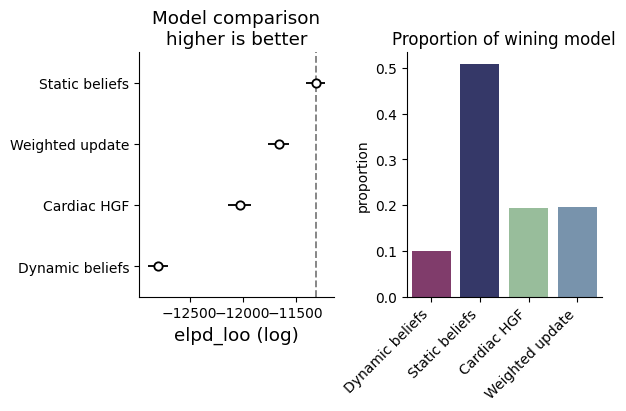

In [10]:
_, axs = plt.subplots(figsize=(6, 4), ncols=2)

az.plot_compare(model_compare, ax=axs[0])
axs[0].set(ylabel="")
axs[0].tick_params(axis="both", which="major", labelsize=10)

this_df = model_comparison_df[model_comparison_df["rank"] == 0]
colors = ["#92c396", "#6f94b5", "#dca8ae", "#a2618c"]
sns.countplot(
    this_df,
    x="model",
    stat="proportion",
    palette=["#8b3170", "#2c3071", "#92c396", "#6f94b5"],
    ax=axs[1],
)
axs[1].set_xticklabels(
    ["Dynamic beliefs", "Static beliefs", "Cardiac HGF", "Weighted update"],
    rotation=45,
    ha="right",
    fontsize=10,
)
axs[1].set(title="Proportion of wining model", xlabel=None)

sns.despine()

plt.savefig(
    Path().cwd().parent.parent / "figures" / "figure_5_model_comparison.svg",
    bbox_inches="tight",
)

In [11]:
print(f"Bayesian psychophysics: {sum(this_df.index == "standard")}")
print(f"Cardiac beliefs: {sum(this_df.index == "cardiac_beliefs")}")
print(f"Weighted update: {sum(this_df.index == "weighted")}")
print(f"Cardiac HGF: {sum(this_df.index == "cardiac_hgf")}")

Bayesian psychophysics: 52
Cardiac beliefs: 263
Weighted update: 102
Cardiac HGF: 101
